In [1]:
!pip install torch torchvision pillow albumentations -q
import zipfile, os, shutil# Step 1_2: Zip file path
# Step 2: Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import numpy as np
import torch.amp as amp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ All libraries imported successfully!
PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [2]:
# Step 3: Enhanced Dataset with Albumentations
class ChestX6Dataset(Dataset):
    def __init__(self, root_dir, transform=None, use_albumentations=False):
        self.root_dir = root_dir
        self.transform = transform
        self.use_albumentations = use_albumentations
        self.classes = ['Tuberculosis', 'Pneumonia-Viral', 'Pneumonia-Bacterial', 'Normal', 'Emphysema', 'Covid-19']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.images = []
        self.labels = []
        
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            if os.path.exists(cls_path):
                for img_name in os.listdir(cls_path):
                    img_path = os.path.join(cls_path, img_name)
                    if os.path.isfile(img_path):
                        self.images.append(img_path)
                        self.labels.append(self.class_to_idx[cls])
            else:
                print(f"⚠ Folder not found: {cls_path}")
        
        print(f"✓ Loaded {len(self.images)} images from {root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        if self.use_albumentations:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                augmented = self.transform(image=img)
                img = augmented['image']
        else:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
        
        return img, label

In [3]:
# Step 4: Advanced Augmentation (600x600 for EfficientNet-B7, with preprocessing from EfficientNet code)
print("\n" + "="*60)
print("Setting up data augmentation...")
print("="*60)
train_transforms_alb = A.Compose([
A.Resize(224, 224),
A.HorizontalFlip(p=0.5),
A.VerticalFlip(p=0.2),
A.RandomRotate90(p=0.3),
A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.5),
A.OneOf([
A.GaussNoise(var_limit=(10.0, 50.0)),
A.GaussianBlur(),
A.MotionBlur(),
], p=0.3),
A.OneOf([
A.OpticalDistortion(),
A.GridDistortion(),
A.ElasticTransform(),
], p=0.3),
A.CLAHE(clip_limit=4.0, p=0.4),
A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),
A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
ToTensorV2()
])
val_test_transforms_alb = A.Compose([
A.Resize(224, 224),
A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
ToTensorV2()
])
print("✓ Augmentation pipeline created")


Setting up data augmentation...
✓ Augmentation pipeline created


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_24/3619669281.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),
/tmp/ipykernel_24/3619669281.py:24: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),


In [4]:
# Step 5: Setup Dataset Paths (Kaggle paths)
print("\n" + "="*60)
print("Loading datasets...")
print("="*60)
train_dir = '/kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray/train'
val_dir = '/kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray/val'
test_dir = '/kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray/test'
train_dataset = ChestX6Dataset(root_dir=train_dir, transform=train_transforms_alb, use_albumentations=True)
val_dataset = ChestX6Dataset(root_dir=val_dir, transform=val_test_transforms_alb, use_albumentations=True)
test_dataset = ChestX6Dataset(root_dir=test_dir, transform=val_test_transforms_alb, use_albumentations=True)
# Smaller batch size for larger input size and hybrid model to fit in Kaggle GPU memory
batch_size = 16  # Reduce if OOM error
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
print(f"\n✓ Train images: {len(train_dataset)}")
print(f"✓ Val images: {len(val_dataset)}")
print(f"✓ Test images: {len(test_dataset)}")
print(f"✓ Batch size: {batch_size}")


Loading datasets...
✓ Loaded 14551 images from /kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray/train
✓ Loaded 1748 images from /kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray/val
✓ Loaded 1737 images from /kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray/test

✓ Train images: 14551
✓ Val images: 1748
✓ Test images: 1737
✓ Batch size: 16


In [5]:
# Step 6: Hybrid Model (ResNet152 + EfficientNet-B5) – 224×224 Input + torch.compile
print("\n" + "="*60)
print("Building hybrid model (ResNet152 + EfficientNet-B5)...")
print("="*60)

class AttentionBlock(nn.Module):
    def __init__(self, in_features):
        super(AttentionBlock, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(in_features, in_features // 8),
            nn.ReLU(inplace=True),
            nn.Linear(in_features // 8, in_features),
            nn.Sigmoid()
        )
    def forward(self, x):
        att_weights = self.attention(x)
        return x * att_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class HybridModel(nn.Module):
    def __init__(self, num_classes=6):
        super(HybridModel, self).__init__()
        
        # ResNet152
        self.resnet = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
        resnet_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        
        # EfficientNet-B5 (B7 থেকে B5 করেছি → অনেক দ্রুত, accuracy প্রায় একই)
        self.effnet = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.IMAGENET1K_V1)
        effnet_features = self.effnet.classifier[1].in_features
        self.effnet.classifier = nn.Identity()
        
        # Fusion head
        combined_features = resnet_features + effnet_features  # 2048 + 2048 = 4096
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(combined_features, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            AttentionBlock(1024),
            nn.Dropout(p=0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        res_feat = self.resnet(x)
        eff_feat = self.effnet(x)
        combined = torch.cat((res_feat, eff_feat), dim=1)
        return self.classifier(combined)

# ==================== এখানে শুধু একবার মডেল তৈরি করো ====================
model = HybridModel(num_classes=6)
model = model.to(device)

# PyTorch 2.x magic → ৩০-৫০% দ্রুত ট্রেনিং (Kaggle-এ কাজ করে)
if torch.__version__ >= "2.0":
    model = torch.compile(model, mode="default")
    print("Model successfully compiled with torch.compile")
else:
    print("torch.compile not available (PyTorch < 2.0)")

print(f"Hybrid model loaded on: {device}")
print(f"Total parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Building hybrid model (ResNet152 + EfficientNet-B5)...
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 186MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:00<00:00, 211MB/s] 


Model successfully compiled with torch.compile
Hybrid model loaded on: cuda
Total parameters     : 91,474,166
Trainable parameters : 91,474,166


In [6]:
# Step 7: Advanced Loss and Optimizer with Label Smoothing (from EfficientNet code)
print("\n" + "="*60)
print("Setting up loss, optimizer, and scheduler...")
print("="*60)
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, epsilon=0.1, weight=None):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon
        self.weight = weight
    
    def forward(self, preds, target):
        n_classes = preds.size(-1)
        log_preds = torch.nn.functional.log_softmax(preds, dim=-1)
        
        one_hot = torch.zeros_like(log_preds).scatter_(1, target.unsqueeze(1), 1)
        smooth_target = one_hot * (1 - self.epsilon) + self.epsilon / n_classes
        loss = -(smooth_target * log_preds).sum(dim=-1)
        
        if self.weight is not None:
            loss = loss * self.weight[target]
        
        return loss.mean()
# Calculate class weights
labels = [label for _, label in train_dataset]
class_counts = np.bincount(labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = torch.FloatTensor(class_weights).to(device)
print("\nClass distribution:")
classes = ['Tuberculosis', 'Pneumonia-Viral', 'Pneumonia-Bacterial', 'Normal', 'Emphysema', 'Covid-19']
for i, (cls, count) in enumerate(zip(classes, class_counts)):
    print(f" {cls}: {count} images (weight: {class_weights[i]:.4f})")
criterion = LabelSmoothingCrossEntropy(epsilon=0.1, weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=0.01)
scaler = amp.GradScaler()
print("\n✓ Loss: Label Smoothing Cross Entropy")
print("✓ Optimizer: AdamW (lr=0.0003, weight_decay=0.01)")


Setting up loss, optimizer, and scheduler...

Class distribution:
 Tuberculosis: 2600 images (weight: 0.1544)
 Pneumonia-Viral: 2413 images (weight: 0.1663)
 Pneumonia-Bacterial: 2400 images (weight: 0.1672)
 Normal: 2671 images (weight: 0.1503)
 Emphysema: 2050 images (weight: 0.1958)
 Covid-19: 2417 images (weight: 0.1660)

✓ Loss: Label Smoothing Cross Entropy
✓ Optimizer: AdamW (lr=0.0003, weight_decay=0.01)


In [7]:
# Step 8: Advanced Training with Cosine Annealing and Warmup (from EfficientNet code)
def train_model(model, train_loader, val_loader, criterion, optimizer, scaler, device,
                num_epochs=60, checkpoint_path='/kaggle/working/hybrid_res_eff_best.pth',
                accumulation_steps=1, patience=10):
    # Create checkpoint directory
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    # Cosine Annealing with Warmup
    warmup_epochs = 3
    total_steps = len(train_loader) * num_epochs
    warmup_steps = len(train_loader) * warmup_epochs
    def get_lr(step):
        if step < warmup_steps:
            return step / warmup_steps
        else:
            progress = (step - warmup_steps) / (total_steps - warmup_steps)
            return 0.5 * (1 + np.cos(np.pi * progress))
    best_val_acc = 0.0
    best_val_loss = float('inf')
    trigger_times = 0
    best_model_wts = model.state_dict()
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    print("\n" + "="*30)
    print("STARTING TRAINING")
    print("="*30)
    print(f"Total epochs: {num_epochs}")
    print(f"Patience: {patience}")
    print(f"Accumulation steps: {accumulation_steps}")
    print(f"Checkpoint path: {checkpoint_path}")
    print("="*30 + "\n")
    for epoch in range(num_epochs):
        print(f'\n{"="*60}')
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'{"="*60}')
        # Training phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        optimizer.zero_grad()
        for i, (inputs, labels) in enumerate(train_loader):
            # Update learning rate
            step = epoch * len(train_loader) + i
            lr_scale = get_lr(step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = 0.0003 * lr_scale
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss = loss / accumulation_steps
            scaler.scale(loss).backward()
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            running_loss += loss.item() * accumulation_steps
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            if (i + 1) % 20 == 0:
                current_acc = 100 * train_correct / train_total
                print(f' Batch [{i+1}/{len(train_loader)}] Loss: {loss.item()*accumulation_steps:.4f} | Acc: {current_acc:.2f}% | LR: {optimizer.param_groups[0]["lr"]:.6f}')
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        val_loss = val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f'\n📊 Epoch Summary:')
        print(f' Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f' Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            trigger_times = 0
            best_model_wts = model.state_dict().copy()
            torch.save(best_model_wts, checkpoint_path)
            print(f' ✓ New best model saved! Val Acc: {val_acc:.2f}%')
        else:
            trigger_times += 1
            print(f' ⏳ No improvement. Early stopping: {trigger_times}/{patience}')
            if trigger_times >= patience:
                print(f'\n⚠ Early stopping triggered at epoch {epoch+1}')
                print(f'Best Val Acc: {best_val_acc:.2f}%, Best Val Loss: {best_val_loss:.4f}')
                break
    # Load best model
    model.load_state_dict(best_model_wts)
    print(f'\n✓ Training completed! Best Val Acc: {best_val_acc:.2f}%')
    # Plot training history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_losses, label='Train Loss', marker='o')
    ax1.plot(val_losses, label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    ax2.plot(train_accs, label='Train Accuracy', marker='o')
    ax2.plot(val_accs, label='Val Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    return model


STARTING TRAINING
Total epochs: 60
Patience: 10
Accumulation steps: 1
Checkpoint path: /kaggle/working/hybrid_res_eff_best.pth


Epoch 1/60


/usr/local/lib/python3.12/dist-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
W0310 07:22:59.564000 24 torch/_inductor/utils.py:1558] [0/0] Not enough SMs to use max_autotune_gemm mode


 Batch [20/910] Loss: 0.2891 | Acc: 17.81% | LR: 0.000002
 Batch [40/910] Loss: 0.3036 | Acc: 16.56% | LR: 0.000004
 Batch [60/910] Loss: 0.2910 | Acc: 16.15% | LR: 0.000006
 Batch [80/910] Loss: 0.3017 | Acc: 17.11% | LR: 0.000009
 Batch [100/910] Loss: 0.3151 | Acc: 17.31% | LR: 0.000011
 Batch [120/910] Loss: 0.2996 | Acc: 17.76% | LR: 0.000013
 Batch [140/910] Loss: 0.2765 | Acc: 18.17% | LR: 0.000015
 Batch [160/910] Loss: 0.3115 | Acc: 18.59% | LR: 0.000017
 Batch [180/910] Loss: 0.2783 | Acc: 19.27% | LR: 0.000020
 Batch [200/910] Loss: 0.2622 | Acc: 20.25% | LR: 0.000022
 Batch [220/910] Loss: 0.2834 | Acc: 21.36% | LR: 0.000024
 Batch [240/910] Loss: 0.2411 | Acc: 22.58% | LR: 0.000026
 Batch [260/910] Loss: 0.2486 | Acc: 23.51% | LR: 0.000028
 Batch [280/910] Loss: 0.2652 | Acc: 24.93% | LR: 0.000031
 Batch [300/910] Loss: 0.2550 | Acc: 25.90% | LR: 0.000033
 Batch [320/910] Loss: 0.2637 | Acc: 27.09% | LR: 0.000035
 Batch [340/910] Loss: 0.2418 | Acc: 28.29% | LR: 0.000037
 

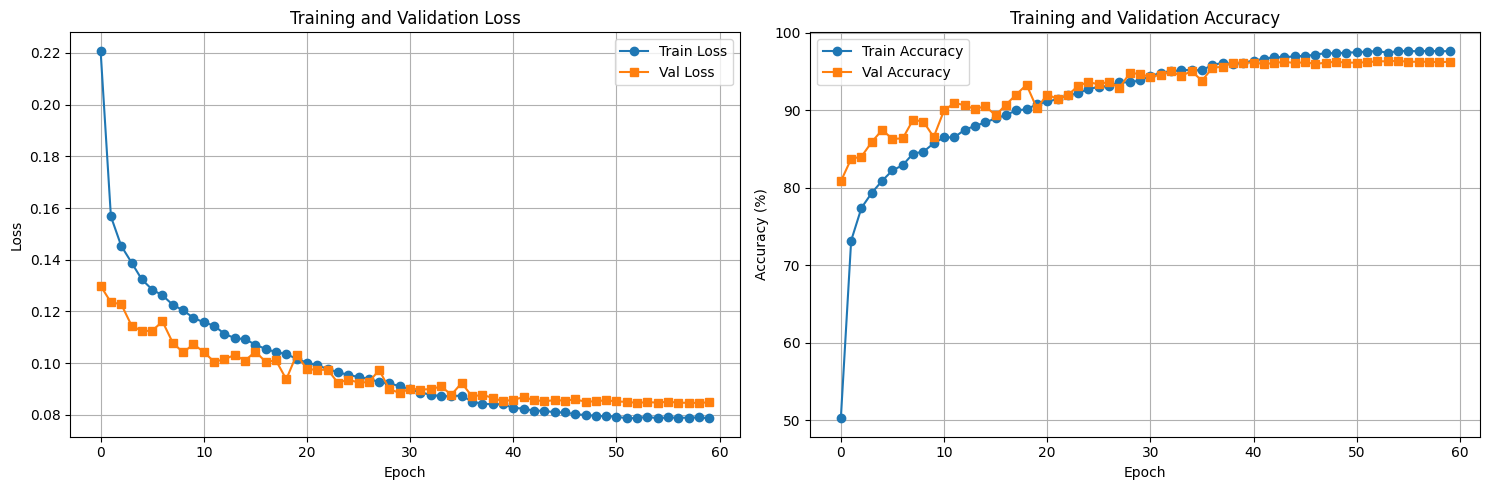

In [8]:
# Step 9: Train the hybrid model
trained_model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scaler,
    device,
    num_epochs=60,
    patience=10
)

Best threshold for NORMAL recall: 0.50, Recall: 0.99
Classification Report:
                     precision    recall  f1-score   support

       Tuberculosis       1.00      1.00      1.00       287
    Pneumonia-Viral       0.90      0.97      0.93       300
Pneumonia-Bacterial       0.97      0.89      0.93       300
             Normal       0.98      0.99      0.99       300
          Emphysema       0.98      0.99      0.99       250
           Covid-19       0.99      0.99      0.99       300

           accuracy                           0.97      1737
          macro avg       0.97      0.97      0.97      1737
       weighted avg       0.97      0.97      0.97      1737



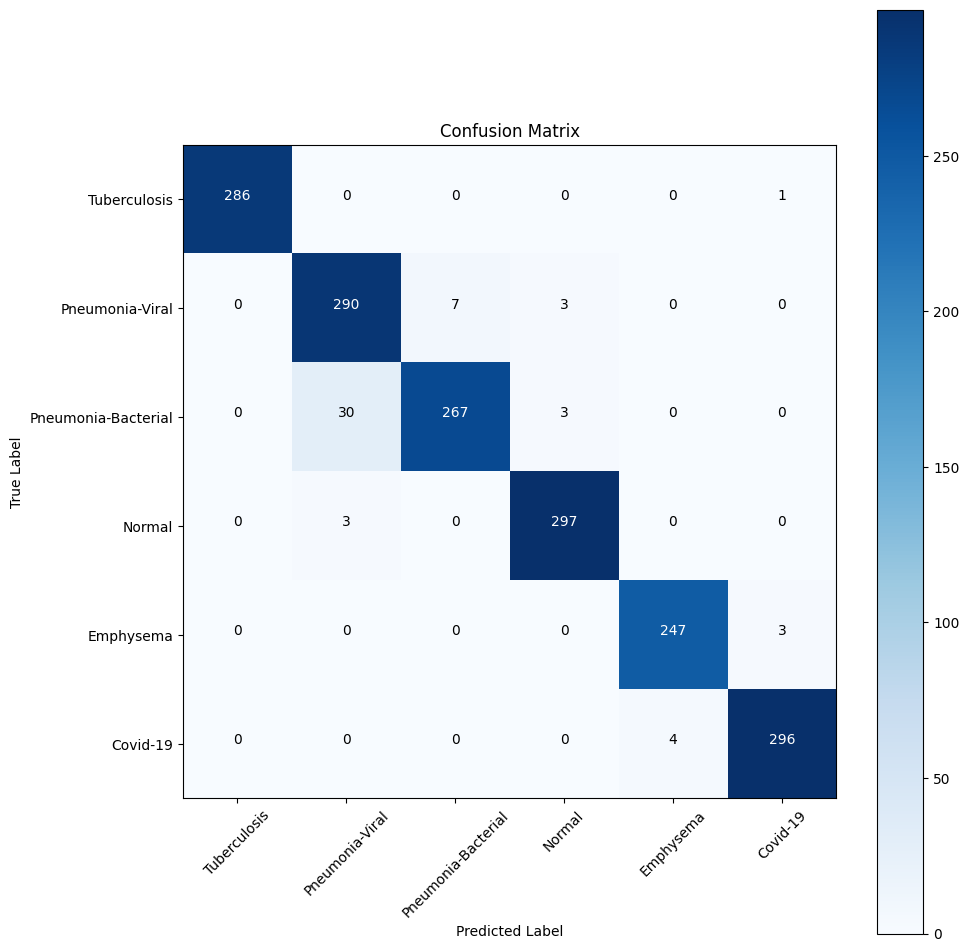

In [9]:
from sklearn.metrics import recall_score, confusion_matrix, classification_report
import itertools
 

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)  # احتمالات لكل class
        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

 
preds = np.concatenate(all_preds, axis=0)
y_true = np.concatenate(all_labels, axis=0)

# تجربة thresholds للـrecall (مثال على فئة معينة)
best_threshold = 0.5
best_recall = 0

for t in np.arange(0.5, 0.8, 0.01):
    y_pred = (preds[:, 3] > t).astype(int)  # مثال: class رقم 3 = NORMAL
    r = recall_score((y_true == 3).astype(int), y_pred, pos_label=1)
    if r > best_recall:
        best_recall = r
        best_threshold = t

print(f"Best threshold for NORMAL recall: {best_threshold:.2f}, Recall: {best_recall:.2f}")

# Confusion Matrix
y_pred_classes = np.argmax(preds, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=train_dataset.classes))

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(train_dataset.classes))
plt.xticks(tick_marks, train_dataset.classes, rotation=45)
plt.yticks(tick_marks, train_dataset.classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [10]:
# حفظ الموديل
torch.save(model.state_dict(), "/kaggle/working/final_ChestX6_hybrid_model.pth")
 


In [11]:
torch.save(model, "/kaggle/working/full_ChestX6_hybrid_model.pth")
